In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import distance
from tem import world, model
from pathlib import Path
import itertools
import polars as pl
import seaborn as sns
import torch
from tbparse import SummaryReader
config_file = "../envs/mckenzie2024.json"
out_dir = Path("~/Dropbox/work/tem/McKenzie").expanduser() / "study-5"
out_dir.mkdir(exist_ok=True)

In [5]:
design = world.design_mckenzie(config_file)
nodes = (
    ["".join(c) for c in itertools.product(["C1", "C2"], ["AB", "BA", "CD", "DC"])]
    + ["".join(c) for c in itertools.product(["C1", "C2"], ["L", "R"], ["A", "B", "C", "D"], ["R", "N"])]
)
n_runs = 1
for run in range(1, n_runs + 1):
    world.learn_mckenzie(design, nodes, out_dir, run)

In [6]:
param_file = out_dir / "sub-001_run-1_params.pt"
params = torch.load(param_file, weights_only=False)
tem_model = model.Model(params)
walks = world.walks_mckenzie(design, nodes, params["n_x"])

g_state = []
p_state = []
with torch.no_grad():
    for walk in walks:
        forward = tem_model(walk, prev_iter=None)
        for step in forward:
            g_module = []
            p_module = []
            # g_module.append(step.g_inf[-1][0].numpy())
            for f in range(tem_model.hyper["n_f"]):
                g_module.append(step.g_inf[f][0].numpy())
                p_module.append(step.p_inf[f][0].numpy())
            g_state.append(np.concat(g_module))
            p_state.append(np.concat(p_module))
g = np.vstack(g_state)
p = np.vstack(p_state)

In [15]:
_, unique_ind = np.unique(design["node"].to_numpy()[::-1], return_index=True)
trial_ind = len(design) - unique_ind - 1

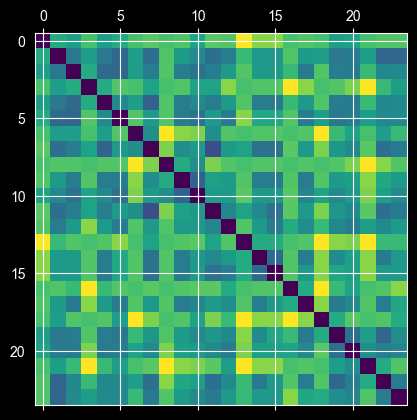

In [23]:
rdm = distance.squareform(distance.pdist(p[trial_ind, :], metric="euclidean"))
d = {f: design[trial_ind][f].to_numpy() for f in ['context', 'object_set', 'object', 'action', 'valence']}
ind = np.lexsort([d[f] for f in ['action', 'valence', 'object', 'object_set', 'context']])
plt.matshow(rdm[np.ix_(ind, ind)], cmap="viridis")

In [26]:
design[trial_ind]

phase,trial,context,object_set,node,action,object,valence,trial_type
str,i64,str,str,str,str,str,str,str
"""ABCD""",997,"""C1""","""AB""","""C1AB""","""L""","""A""","""R""","""choice"""
"""ABCD""",995,"""C1""","""AB""","""C1BA""","""L""","""B""","""N""","""choice"""
"""CD""",998,"""C1""","""CD""","""C1CD""","""L""","""C""","""R""","""choice"""
"""CD""",1000,"""C1""","""CD""","""C1DC""","""R""","""C""","""R""","""choice"""
"""ABCD""",997,"""C1""","""AB""","""C1LAR""","""L""","""A""","""R""","""feedback"""
…,…,…,…,…,…,…,…,…
"""CD""",997,"""C2""","""CD""","""C2LDR""","""L""","""D""","""R""","""feedback"""
"""ABCD""",994,"""C2""","""AB""","""C2RAN""","""R""","""A""","""N""","""feedback"""
"""ABCD""",986,"""C2""","""AB""","""C2RBR""","""R""","""B""","""R""","""feedback"""


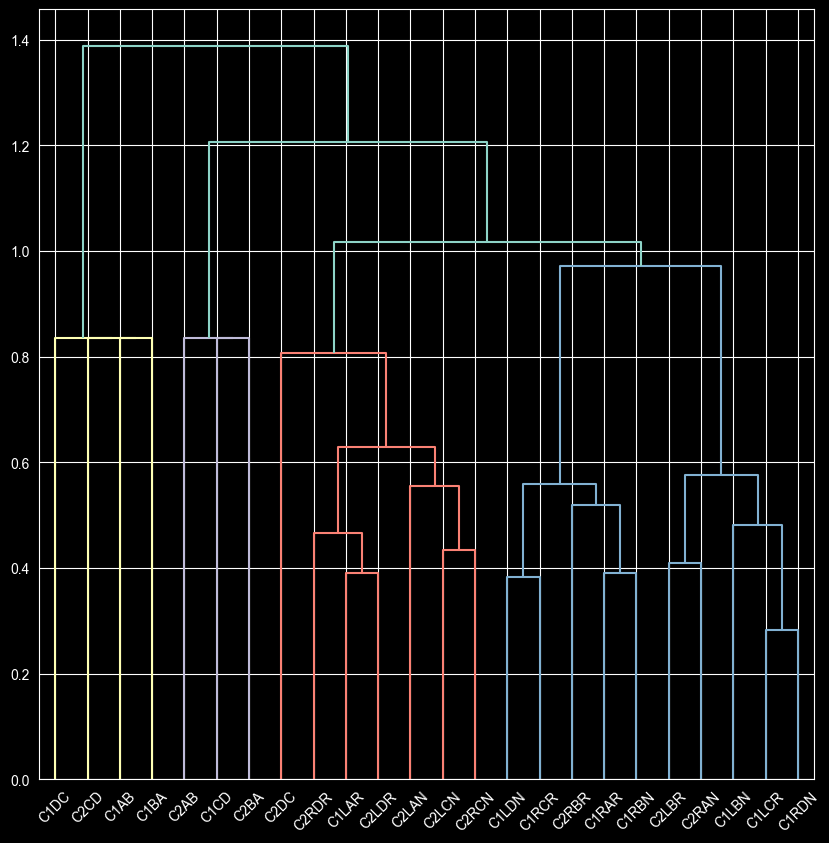

In [27]:
from scipy.cluster import hierarchy
linkage_data = hierarchy.linkage(p[trial_ind, :], method="ward", metric="euclidean")
fig, ax = plt.subplots(figsize=(10, 10))
hierarchy.dendrogram(linkage_data, ax=ax, labels=design[trial_ind]["node"])

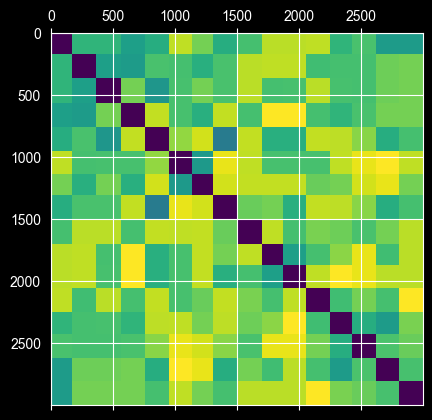

In [32]:
#trial_ind = slice(None, None)
rdm = distance.squareform(distance.pdist(p[trial_ind, :], metric="euclidean"))
# rdm_feedback = rdm[1::2, 1::2]
d = {f: design[trial_ind].filter(trial_type='feedback')[f].to_numpy() for f in ['context', 'object_set', 'object', 'action', 'valence']}
d_ind = {f: np.argsort(v) for f, v in d.items()}
feat = 'action'
ind = np.lexsort([d[f] for f in ['action', 'valence', 'object', 'object_set', 'context']])
#plt.matshow(rdm_feedback[np.ix_(d_ind[feat], d_ind[feat])], cmap='viridis')
plt.matshow(rdm_feedback[np.ix_(ind, ind)], cmap="viridis")

In [31]:
design[trial_ind].filter(trial_type='feedback')[ind]

phase,trial,context,object_set,node,action,object,valence,trial_type
str,i64,str,str,str,str,str,str,str
"""AB""",3,"""C1""","""AB""","""C1LAR""","""L""","""A""","""R""","""feedback"""
"""AB""",5,"""C1""","""AB""","""C1LAR""","""L""","""A""","""R""","""feedback"""
"""AB""",7,"""C1""","""AB""","""C1LAR""","""L""","""A""","""R""","""feedback"""
"""AB""",11,"""C1""","""AB""","""C1LAR""","""L""","""A""","""R""","""feedback"""
"""AB""",15,"""C1""","""AB""","""C1LAR""","""L""","""A""","""R""","""feedback"""
…,…,…,…,…,…,…,…,…
"""AB""",960,"""C2""","""AB""","""C2RBR""","""R""","""B""","""R""","""feedback"""
"""AB""",972,"""C2""","""AB""","""C2RBR""","""R""","""B""","""R""","""feedback"""
"""AB""",982,"""C2""","""AB""","""C2RBR""","""R""","""B""","""R""","""feedback"""


In [22]:
design[trial_ind].shape

(2000, 9)

In [ ]:
from scipy.cluster import hierarchy

In [ ]:

linkage_data = hierarchy.linkage(g[1::2, :], method="ward", metric="euclidean")
fig, ax = plt.subplots(figsize=(10, 10))
hierarchy.dendrogram(linkage_data, ax=ax)
# plt.savefig("/Users/nmorton/Downloads/test.pdf")

In [ ]:
subject = "001"
reader = SummaryReader(str(out_dir))
df = (
    pl.DataFrame(reader.scalars)
    .with_columns(
        subject=pl.lit(subject),
        run=pl.col("value").cum_count().over(pl.col("step")),
    )
    .with_columns(
        smooth_value=pl.col("value").rolling_mean(window_size=50).over("tag", "run"),
    )
)

In [ ]:
g = sns.relplot(
    df.filter(pl.col("tag") == "Accuracies/p"),
    x="step",
    y="smooth_value",
    kind="line",
)
g.set(ylabel="Perceptual accuracy")

In [ ]:
g = sns.relplot(
    df.filter(pl.col("tag") == "Accuracies/g"),
    x="step",
    y="smooth_value",
    kind="line",
)
g.set(ylabel="Structural accuracy")